# 07 · MoE Routing: Dense and Sparse, Added Together

**Hardware**: 🟢 CPU, zero downloads. `google/gemma-4-26B-A4B-it` is the only size with MoE and is far too large to run here, so we build a small one with the same structure.

## What you will do

1. Confirm the surprise: the MoE block does **not** replace the dense MLP — both run and their outputs are summed
2. Walk the router: norm → learned scale → softmax → top-k → renormalise → per-expert scale
3. Watch expert dispatch, and see why the weights are stored as 3D tensors
4. Plot expert load and see what imbalance looks like
5. Count how much FFN width a single token actually sees

In [1]:
%pip install -q "transformers>=5.14" torch matplotlib

In [2]:
import collections
import torch
import matplotlib.pyplot as plt
from transformers import Gemma4TextConfig, Gemma4ForCausalLM

torch.manual_seed(0)

# 26B-A4B has num_experts=128, top_k_experts=8, moe_intermediate_size=704,
# and a dense intermediate_size of 2112. Same shape, smaller numbers.
config = Gemma4TextConfig(
    vocab_size=512, hidden_size=64, intermediate_size=96,
    num_hidden_layers=12, num_attention_heads=4, num_key_value_heads=1,
    head_dim=16, global_head_dim=32, sliding_window=8,
    hidden_size_per_layer_input=0,
    enable_moe_block=True, num_experts=16, top_k_experts=4, moe_intermediate_size=32,
)
model = Gemma4ForCausalLM(config).eval()
layer = model.model.layers[0]

  from .autonotebook import tqdm as notebook_tqdm


## 1. Both paths exist

In [3]:
print("dense mlp :", type(layer.mlp).__name__, "| intermediate_size =", layer.mlp.intermediate_size)
print("router    :", type(layer.router).__name__)
print("experts   :", type(layer.experts).__name__)
print("\nextra norms for the two branches:")
for n in ["pre_feedforward_layernorm", "post_feedforward_layernorm",
          "pre_feedforward_layernorm_2", "post_feedforward_layernorm_1",
          "post_feedforward_layernorm_2"]:
    print("   ", n, "->", hasattr(layer, n))

print('''
Gemma4TextDecoderLayer.forward does:

    hidden_states  = self.mlp(pre_feedforward_layernorm(hidden_states))   # dense, always
    hidden_states_1 = post_feedforward_layernorm_1(hidden_states)

    _, w, idx      = self.router(residual)                                 # routes on the layer INPUT
    hidden_states_2 = self.experts(pre_feedforward_layernorm_2(residual), idx, w)
    hidden_states_2 = post_feedforward_layernorm_2(hidden_states_2)

    hidden_states  = hidden_states_1 + hidden_states_2                     # dense + sparse
''')
print("The dense MLP is a SHARED EXPERT that every token gets. Routed experts add")
print("specialisation on top. This is the DeepSeekMoE arrangement: without a shared")
print("path, every expert has to independently relearn the common case.")

dense mlp : Gemma4TextMLP | intermediate_size = 96
router    : Gemma4TextRouter
experts   : Gemma4TextExperts

extra norms for the two branches:
    pre_feedforward_layernorm -> True
    post_feedforward_layernorm -> True
    pre_feedforward_layernorm_2 -> True
    post_feedforward_layernorm_1 -> True
    post_feedforward_layernorm_2 -> True

Gemma4TextDecoderLayer.forward does:

    hidden_states  = self.mlp(pre_feedforward_layernorm(hidden_states))   # dense, always
    hidden_states_1 = post_feedforward_layernorm_1(hidden_states)

    _, w, idx      = self.router(residual)                                 # routes on the layer INPUT
    hidden_states_2 = self.experts(pre_feedforward_layernorm_2(residual), idx, w)
    hidden_states_2 = post_feedforward_layernorm_2(hidden_states_2)

    hidden_states  = hidden_states_1 + hidden_states_2                     # dense + sparse

The dense MLP is a SHARED EXPERT that every token gets. Routed experts add
specialisation on top. This is the Dee

## 2. Expert weights are 3D tensors

In [4]:
e = layer.experts
print("gate_up_proj:", tuple(e.gate_up_proj.shape),
      "= [num_experts, 2*moe_intermediate_size, hidden_size]")
print("down_proj   :", tuple(e.down_proj.shape),
      "= [num_experts, hidden_size, moe_intermediate_size]")
print("\nNot 16 separate nn.Linear modules — one stacked parameter per projection.")
print("That is what lets a distributed backend do a grouped GEMM over all experts")
print("at once (see base_model_ep_plan's 'grouped_gemm' in chapter 01).")

n_expert_params = e.gate_up_proj.numel() + e.down_proj.numel()
n_dense = sum(p.numel() for p in layer.mlp.parameters())
print(f"\nper layer: {n_expert_params:,} expert params vs {n_dense:,} dense params")

gate_up_proj: (16, 64, 64) = [num_experts, 2*moe_intermediate_size, hidden_size]
down_proj   : (16, 64, 32) = [num_experts, hidden_size, moe_intermediate_size]

Not 16 separate nn.Linear modules — one stacked parameter per projection.
That is what lets a distributed backend do a grouped GEMM over all experts
at once (see base_model_ep_plan's 'grouped_gemm' in chapter 01).

per layer: 98,304 expert params vs 18,432 dense params


## 3. The router, step by step

In [5]:
r = layer.router
print("norm  :", r.norm, "  <- with_scale=False, no parameters")
print("scale :", tuple(r.scale.shape), " <- learned PER-DIMENSION scale before projection")
print("proj  :", r.proj)
print("per_expert_scale:", tuple(r.per_expert_scale.shape), " <- learned per-expert gain")

tokens = torch.randn(200, config.hidden_size)
probs, top_k_weights, top_k_index = r(tokens)

print("\nrouter_probabilities:", tuple(probs.shape), "(softmax over all experts, fp32)")
print("top_k_weights       :", tuple(top_k_weights.shape))
print("top_k_index         :", tuple(top_k_index.shape))
print("\nfirst token -> experts", top_k_index[0].tolist())
print("             weights", [round(x, 4) for x in top_k_weights[0].tolist()])
print("\nWeights are renormalised to sum to 1 over the kept k, then multiplied by")
print("per_expert_scale — so they no longer sum to exactly 1:")
print("   sums:", [round(x, 4) for x in top_k_weights.sum(-1)[:5].tolist()])

norm  : Gemma4RMSNorm()   <- with_scale=False, no parameters
scale : (64,)  <- learned PER-DIMENSION scale before projection
proj  : Linear(in_features=64, out_features=16, bias=False)
per_expert_scale: (16,)  <- learned per-expert gain

router_probabilities: (200, 16) (softmax over all experts, fp32)
top_k_weights       : (200, 4)
top_k_index         : (200, 4)

first token -> experts [12, 15, 14, 8]
             weights [0.2521, 0.2516, 0.2488, 0.2475]

Weights are renormalised to sum to 1 over the kept k, then multiplied by
per_expert_scale — so they no longer sum to exactly 1:
   sums: [1.0, 1.0, 1.0, 1.0, 1.0]


## 4. Expert load

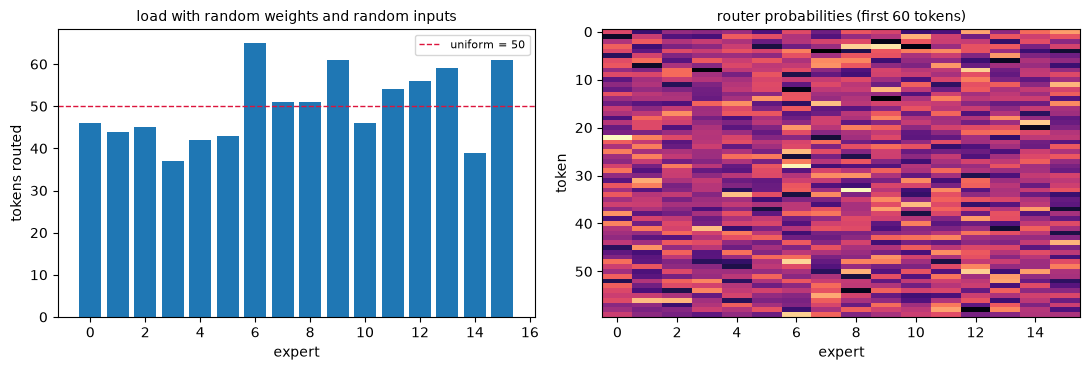

total assignments: 800 = 200 tokens x top-4
load imbalance (max/mean): 1.30x

A trained model's routing is far from uniform — it is specialised. Balance
is encouraged during training; there is no auxiliary loss at inference.


In [6]:
counts = collections.Counter(top_k_index.flatten().tolist())
load = [counts.get(i, 0) for i in range(config.num_experts)]
expected = len(tokens) * config.top_k_experts / config.num_experts

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar(range(config.num_experts), load)
axes[0].axhline(expected, color="crimson", ls="--", lw=1, label=f"uniform = {expected:.0f}")
axes[0].set_xlabel("expert"); axes[0].set_ylabel("tokens routed")
axes[0].set_title("load with random weights and random inputs", fontsize=10)
axes[0].legend(fontsize=8)

axes[1].imshow(probs[:60].detach().numpy(), aspect="auto", cmap="magma")
axes[1].set_xlabel("expert"); axes[1].set_ylabel("token")
axes[1].set_title("router probabilities (first 60 tokens)", fontsize=10)
plt.tight_layout(); plt.show()

print(f"total assignments: {sum(load)} = {len(tokens)} tokens x top-{config.top_k_experts}")
print(f"load imbalance (max/mean): {max(load) / (sum(load)/len(load)):.2f}x")
print("\nA trained model's routing is far from uniform — it is specialised. Balance")
print("is encouraged during training; there is no auxiliary loss at inference.")

## 5. Dispatch

In [7]:
out = layer.experts(tokens, top_k_index, top_k_weights)
print("experts output:", tuple(out.shape), "-> same width as the input, ready to be summed")

print('''
The reference implementation loops only over experts that were actually selected:

    expert_mask = one_hot(top_k_index, num_experts).permute(2, 1, 0)
    expert_hit  = greater(expert_mask.sum(dim=(-1, -2)), 0).nonzero()
    for expert_idx in expert_hit:
        top_k_pos, token_idx = where(expert_mask[expert_idx])
        gate, up = linear(hidden_states[token_idx], gate_up_proj[expert_idx]).chunk(2, -1)
        h = linear(act_fn(gate) * up, down_proj[expert_idx])
        final.index_add_(0, token_idx, h * top_k_weights[token_idx, top_k_pos, None])
''')
print("Readable and slow. @use_experts_implementation swaps in a fused kernel when")
print("one is available — read this version to understand MoE, never run it in production.")

experts output: (200, 64) -> same width as the input, ready to be summed

The reference implementation loops only over experts that were actually selected:

    expert_mask = one_hot(top_k_index, num_experts).permute(2, 1, 0)
    expert_hit  = greater(expert_mask.sum(dim=(-1, -2)), 0).nonzero()
    for expert_idx in expert_hit:
        top_k_pos, token_idx = where(expert_mask[expert_idx])
        gate, up = linear(hidden_states[token_idx], gate_up_proj[expert_idx]).chunk(2, -1)
        h = linear(act_fn(gate) * up, down_proj[expert_idx])
        final.index_add_(0, token_idx, h * top_k_weights[token_idx, top_k_pos, None])

Readable and slow. @use_experts_implementation swaps in a fused kernel when
one is available — read this version to understand MoE, never run it in production.


## 6. How much of the model runs?

In [8]:
def report(num_experts, top_k, moe_inter, dense_inter, label):
    available = num_experts * moe_inter
    used = top_k * moe_inter + dense_inter
    print(f"{label}")
    print(f"   available routed width : {available:,}")
    print(f"   per-token width        : {used:,}  "
          f"({top_k} x {moe_inter} routed + {dense_inter} shared)")
    print(f"   fraction active        : {100 * used / (available + dense_inter):.1f}%\n")

report(config.num_experts, config.top_k_experts, config.moe_intermediate_size,
       config.intermediate_size, "this toy model")
report(128, 8, 704, 2112, "google/gemma-4-26B-A4B-it")

print("128 experts choose-8 gives astronomically more expert *combinations* per token")
print("than Mixtral's 8 choose-2 — that is what 'fine-grained' MoE buys, at the cost of")
print("more routing overhead and harder load balancing.")

this toy model
   available routed width : 512
   per-token width        : 224  (4 x 32 routed + 96 shared)
   fraction active        : 36.8%

google/gemma-4-26B-A4B-it
   available routed width : 90,112
   per-token width        : 7,744  (8 x 704 routed + 2112 shared)
   fraction active        : 8.4%

128 experts choose-8 gives astronomically more expert *combinations* per token
than Mixtral's 8 choose-2 — that is what 'fine-grained' MoE buys, at the cost of
more routing overhead and harder load balancing.


## Exercises

1. Set `top_k_experts=1`. What happens to the renormalisation step, and what does that imply about `per_expert_scale`?
2. Feed the router 200 copies of the *same* token. How many distinct experts fire, and why?
3. Bypass the router: call `layer.experts` with hand-built `top_k_index` sending every token to expert 0. Compare the output with running expert 0's projections manually.
4. The router reads `residual` (the layer input), not the post-MLP hidden state. Change it to route on the post-MLP state and argue which is better.
5. Compute the parameter count of one 26B-A4B MoE layer from its config, and check it against 26B total across 30 layers.
6. Set `enable_moe_block=True` on some layers only, by building `Gemma4TextDecoderLayer`s directly. Does the config support that? Should it?

## Where next

[Chapter 08](../../08-fusion-and-masks/index.md) — where the modalities finally meet.